# 02. 대표 빈티지 전환 규칙 EDA

`same-vintage` 타겟과 비교할 수 있는 **연속 대표 VWAP 시계열**을 만들 수 있는지 확인한다.  
확인해야 할 점은 빈티지 겹침 구간에서 거래량 우위가 언제 다음 빈티지로 넘어가는지, 그 시점의 가격 점프가 얼마나 큰지이다.

In [40]:
# 1. 환경 설정
from pathlib import Path
import os
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

if Path('/mnt/hgfs/Windows/Climate').exists():
    PROJECT_ROOT = Path('/mnt/hgfs/Windows/Climate')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.rcParams['axes.unicode_minus'] = False

In [41]:
# 2. DB 연결 및 KRX ETS 원천 데이터 로드
load_dotenv(PROJECT_ROOT / '.env')
required_keys = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [key for key in required_keys if not os.getenv(key)]
if missing:
    raise RuntimeError(f'필수 DB 환경변수가 없습니다: {missing}')

user = os.getenv('DB_USER')
password = quote_plus(os.getenv('DB_PASSWORD'))
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}')

query = """
select
    period,
    trd_dd,
    isu_code,
    clsprc,
    acc_trdvol,
    acc_trdval,
    vwap
from raw.krx_ets_daily
order by trd_dd, isu_code
"""

ets = pd.read_sql(query, engine, parse_dates=['trd_dd'])
ets['isu_year'] = ets['isu_code'].str.extract(r'(\d{2})$')[0].astype('Int64') + 2000
ets['is_trade_day'] = (ets['acc_trdvol'] > 0) & (ets['vwap'] > 0)
ets_trade = ets[ets['is_trade_day']].copy()

load_summary = pd.DataFrame({
    '항목': ['전체 행 수', '실제 거래 행 수', '시작일', '종료일', '실제 거래 빈티지 수'],
    '값': [
        len(ets),
        len(ets_trade),
        ets['trd_dd'].min().date(),
        ets['trd_dd'].max().date(),
        ets_trade['isu_code'].nunique(),
    ],
})
load_summary

,항목,값
0,전체 행 수,8213
1,실제 거래 행 수,2385
2,시작일,2015-01-12
3,종료일,2026-04-23
4,실제 거래 빈티지 수,11


In [42]:
# 3. 실제 거래가 있는 빈티지와 인접 빈티지 pair 구성
# vintage_pairs: KAU15 -> KAU16처럼 연도 순서상 인접한 빈티지 쌍이다.

vintage_info = (
    ets_trade.groupby('isu_code')
    .agg(
        isu_year=('isu_year', 'first'),
        trade_start=('trd_dd', 'min'),
        trade_end=('trd_dd', 'max'),
        trade_obs=('trd_dd', 'size'),
        total_volume=('acc_trdvol', 'sum'),
    )
    .reset_index()
    .sort_values('isu_year')
)

active_codes = vintage_info['isu_code'].tolist()
vintage_pairs = list(zip(active_codes[:-1], active_codes[1:]))

vintage_info_display = vintage_info.rename(columns={
    'isu_code': '빈티지',
    'isu_year': '빈티지 연도',
    'trade_start': '거래 시작일',
    'trade_end': '거래 종료일',
    'trade_obs': '실제 거래일 수',
    'total_volume': '총 거래량',
})

vintage_info_display.style.format({
    '실제 거래일 수': '{:,.0f}',
    '총 거래량': '{:,.0f}',
})

,빈티지,빈티지 연도,거래 시작일,거래 종료일,실제 거래일 수,총 거래량
0,KAU15,2015,2015-01-12 00:00:00,2016-06-23 00:00:00,33,"1,620,224"
1,KAU16,2016,2016-07-04 00:00:00,2017-06-30 00:00:00,134,"8,993,600"
2,KAU17,2017,2017-02-06 00:00:00,2018-08-09 00:00:00,250,"21,754,596"
3,KAU18,2018,2018-01-17 00:00:00,2019-09-27 00:00:00,154,"7,520,475"
4,KAU19,2019,2019-01-22 00:00:00,2020-09-11 00:00:00,291,"10,511,590"
5,KAU20,2020,2019-09-24 00:00:00,2021-08-09 00:00:00,285,"13,974,616"
6,KAU21,2021,2021-01-14 00:00:00,2022-08-08 00:00:00,266,"10,402,374"
7,KAU22,2022,2022-06-14 00:00:00,2023-08-31 00:00:00,284,"48,141,257"
8,KAU23,2023,2023-06-20 00:00:00,2024-08-30 00:00:00,267,"67,971,324"
9,KAU24,2024,2024-06-27 00:00:00,2025-08-29 00:00:00,248,"72,101,808"


In [43]:
# 4. 인접 빈티지의 실제 거래 겹침 구간 생성
# pair_overlap: 같은 날짜에 현재 빈티지와 다음 빈티지가 모두 실제 거래된 행만 포함한다.

def build_pair_overlap(df, pairs):
    pair_frames = []
    base_cols = ['trd_dd', 'isu_code', 'vwap', 'acc_trdvol', 'acc_trdval']

    for current_code, next_code in pairs:
        current = (
            df.loc[df['isu_code'].eq(current_code), base_cols]
            .rename(columns={
                'isu_code': 'current_isu_code',
                'vwap': 'current_vwap',
                'acc_trdvol': 'current_volume',
                'acc_trdval': 'current_value',
            })
        )
        nxt = (
            df.loc[df['isu_code'].eq(next_code), base_cols]
            .rename(columns={
                'isu_code': 'next_isu_code',
                'vwap': 'next_vwap',
                'acc_trdvol': 'next_volume',
                'acc_trdval': 'next_value',
            })
        )
        merged = current.merge(nxt, on='trd_dd', how='inner')
        if merged.empty:
            continue
        merged['pair'] = f'{current_code}->{next_code}'
        merged['volume_ratio_next_to_current'] = merged['next_volume'] / merged['current_volume']
        merged['next_volume_gt_current'] = merged['next_volume'] > merged['current_volume']
        merged['log_price_gap_next_to_current'] = np.log(merged['next_vwap'] / merged['current_vwap'])
        pair_frames.append(merged)

    if not pair_frames:
        return pd.DataFrame()
    return pd.concat(pair_frames, ignore_index=True).sort_values(['pair', 'trd_dd'])

pair_overlap = build_pair_overlap(ets_trade, vintage_pairs)
print('인접 빈티지 겹침 관측치 수:', len(pair_overlap))
pair_overlap.head()

인접 빈티지 겹침 관측치 수: 253


,trd_dd,current_isu_code,current_vwap,current_volume,current_value,next_isu_code,next_vwap,next_volume,next_value,pair,volume_ratio_next_to_current,next_volume_gt_current,log_price_gap_next_to_current
0,2017-02-06,KAU16,26000,5000,130000000,KAU17,25900,2746,71121400,KAU16->KAU17,0.549200,False,-0.003854
1,2017-03-06,KAU16,23700,10532,249608400,KAU17,23000,24500,563500000,KAU16->KAU17,2.326244,True,-0.029981
2,2017-03-09,KAU16,22950,10000,229500000,KAU17,22500,25000,562500000,KAU16->KAU17,2.500000,True,-0.019803
3,2017-03-16,KAU16,21400,105000,2247000000,KAU17,21400,20000,428000000,KAU16->KAU17,0.190476,False,0.000000
4,2017-03-20,KAU16,21720,5000,108600000,KAU17,20200,8000,161600000,KAU16->KAU17,1.600000,True,-0.072551


In [44]:
# 5. 인접 빈티지별 겹침 구간 요약
# next_volume_gt_current_rate: 겹침 구간 중 다음 빈티지 거래량이 현재 빈티지보다 큰 날짜의 비율이다.

overlap_summary = (
    pair_overlap.groupby('pair')
    .agg(
        overlap_trade_days=('trd_dd', 'size'),
        overlap_start=('trd_dd', 'min'),
        overlap_end=('trd_dd', 'max'),
        next_volume_gt_current_days=('next_volume_gt_current', 'sum'),
        next_volume_gt_current_rate=('next_volume_gt_current', 'mean'),
        median_log_price_gap=('log_price_gap_next_to_current', 'median'),
        p95_abs_log_price_gap=('log_price_gap_next_to_current', lambda x: x.abs().quantile(0.95)),
    )
    .reset_index()
)

overlap_summary_display = overlap_summary.rename(columns={
    'pair': '빈티지 pair',
    'overlap_trade_days': '동시 거래일 수',
    'overlap_start': '겹침 시작일',
    'overlap_end': '겹침 종료일',
    'next_volume_gt_current_days': '다음 빈티지 거래량 우위일 수',
    'next_volume_gt_current_rate': '다음 빈티지 거래량 우위 비율',
    'median_log_price_gap': '가격 gap 중앙값',
    'p95_abs_log_price_gap': '|가격 gap| 95% 분위',
})

overlap_summary_display.style.format({
    '동시 거래일 수': '{:,.0f}',
    '다음 빈티지 거래량 우위일 수': '{:,.0f}',
    '다음 빈티지 거래량 우위 비율': '{:.1%}',
    '가격 gap 중앙값': '{:.3f}',
    '|가격 gap| 95% 분위': '{:.3f}',
})

,빈티지 pair,동시 거래일 수,겹침 시작일,겹침 종료일,다음 빈티지 거래량 우위일 수,다음 빈티지 거래량 우위 비율,가격 gap 중앙값,|가격 gap| 95% 분위
0,KAU16->KAU17,29,2017-02-06 00:00:00,2017-06-30 00:00:00,9,31.0%,-0.005,0.045
1,KAU17->KAU18,4,2018-01-17 00:00:00,2018-06-11 00:00:00,1,25.0%,-0.017,0.084
2,KAU18->KAU19,71,2019-01-29 00:00:00,2019-09-27 00:00:00,14,19.7%,0.000,0.107
3,KAU19->KAU20,60,2019-09-24 00:00:00,2020-09-11 00:00:00,16,26.7%,0.028,0.250
4,KAU20->KAU21,21,2021-01-14 00:00:00,2021-08-04 00:00:00,4,19.0%,0.105,0.248
5,KAU21->KAU22,21,2022-06-14 00:00:00,2022-08-08 00:00:00,5,23.8%,0.351,0.566
6,KAU22->KAU23,23,2023-06-20 00:00:00,2023-08-31 00:00:00,0,0.0%,0.017,0.293
7,KAU23->KAU24,8,2024-06-27 00:00:00,2024-08-28 00:00:00,0,0.0%,-0.009,0.190
8,KAU24->KAU25,16,2025-07-03 00:00:00,2025-08-29 00:00:00,0,0.0%,0.009,0.059


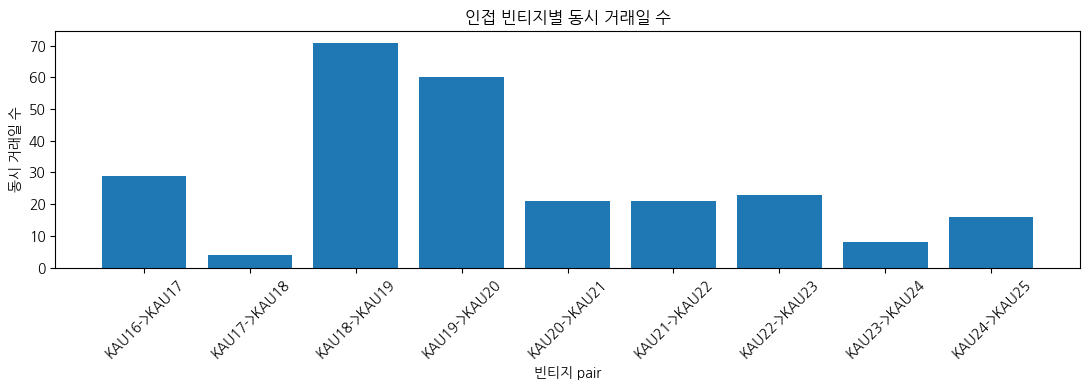

In [45]:
# 6. 인접 빈티지별 동시 거래일 수 시각화
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(overlap_summary['pair'], overlap_summary['overlap_trade_days'])
ax.set_title('인접 빈티지별 동시 거래일 수')
ax.set_xlabel('빈티지 pair')
ax.set_ylabel('동시 거래일 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# 7. volume-confirmed roll 후보 계산 함수
# 기본 조건은 확정된 roll rule이 아니라 문헌에 기반한 가정된 EDA anchor이다.
# rolling_window=20: 약 1개월 거래일 관행을 참고한 기본값.
# 단, 여기서는 calendar day가 아니라 pair_overlap 기준 20개 동시거래 관측치이다.
# confirm_days=5: 일시적 거래량 spike가 아니라 지속적 유동성 이전인지 확인하는 조건이다.
# min_next_volume=1_000: 01_ets_eda의 volume threshold 진단에서 표본을 대부분 유지하는 느슨한 유동성 하한이다.

roll_rule_params = {
    'rolling_window': 20,
    'confirm_days': 5,
    'min_next_volume': 1_000,
}

def find_volume_confirmed_roll(pair_df, rolling_window=20, confirm_days=5, min_next_volume=1_000):
    g = pair_df.sort_values('trd_dd').copy()
    g['current_volume_roll'] = g['current_volume'].rolling(rolling_window, min_periods=1).sum()
    g['next_volume_roll'] = g['next_volume'].rolling(rolling_window, min_periods=1).sum()
    g['next_roll_gt_current_roll'] = g['next_volume_roll'] > g['current_volume_roll']
    g['next_volume_meets_min'] = g['next_volume'] >= min_next_volume
    g['roll_signal'] = g['next_roll_gt_current_roll'] & g['next_volume_meets_min']
    g['roll_signal_run'] = (
        g['roll_signal']
        .astype(int)
        .groupby((~g['roll_signal']).cumsum())
        .cumsum()
    )

    candidates = g[g['roll_signal_run'] >= confirm_days]
    if candidates.empty:
        return None, g

    roll_row = candidates.iloc[0]
    roll_info = {
        'pair': roll_row['pair'],
        'roll_date': roll_row['trd_dd'],
        'current_isu_code': roll_row['current_isu_code'],
        'next_isu_code': roll_row['next_isu_code'],
        'current_vwap': roll_row['current_vwap'],
        'next_vwap': roll_row['next_vwap'],
        'current_volume': roll_row['current_volume'],
        'next_volume': roll_row['next_volume'],
        'current_volume_roll': roll_row['current_volume_roll'],
        'next_volume_roll': roll_row['next_volume_roll'],
        'log_price_gap_next_to_current': roll_row['log_price_gap_next_to_current'],
        'price_ratio_next_to_current': roll_row['next_vwap'] / roll_row['current_vwap'],
        'rolling_window': rolling_window,
        'confirm_days': confirm_days,
        'min_next_volume': min_next_volume,
    }
    return roll_info, g

roll_info, roll_trace = find_volume_confirmed_roll(
    pair_overlap[pair_overlap['pair'].eq(pair_overlap['pair'].iloc[0])],
    **roll_rule_params,
)

In [47]:
# 8. 기본 volume-confirmed roll rule 후보일 계산
# 기본 조건: rolling 20 관측치 거래량 합계, 5일 연속 다음 빈티지 우위, 다음 빈티지 거래량 1,000 이상

roll_candidates = []
roll_traces = {}

for pair, g in pair_overlap.groupby('pair'):
    info, trace = find_volume_confirmed_roll(g, **roll_rule_params)
    roll_traces[pair] = trace
    if info is not None:
        roll_candidates.append(info)

roll_candidates = pd.DataFrame(roll_candidates)

if roll_candidates.empty:
    roll_candidates_display = pd.DataFrame({'메시지': ['기본 조건에서 전환 후보일 없음']})
else:
    roll_candidates_display = roll_candidates.rename(columns={
        'pair': '빈티지 pair',
        'roll_date': '전환 후보일',
        'current_isu_code': '현재 빈티지',
        'next_isu_code': '다음 빈티지',
        'current_vwap': '현재 VWAP',
        'next_vwap': '다음 VWAP',
        'current_volume': '현재 거래량',
        'next_volume': '다음 거래량',
        'current_volume_roll': '현재 rolling 거래량',
        'next_volume_roll': '다음 rolling 거래량',
        'log_price_gap_next_to_current': '전환일 가격 gap',
        'price_ratio_next_to_current': '전환일 가격 비율',
        'rolling_window': 'rolling 관측치 수',
        'confirm_days': '연속 확인일 수',
        'min_next_volume': '다음 빈티지 최소 거래량',
    })

roll_candidates_display

,빈티지 pair,전환 후보일,현재 빈티지,다음 빈티지,현재 VWAP,다음 VWAP,현재 거래량,다음 거래량,현재 rolling 거래량,다음 rolling 거래량,전환일 가격 gap,전환일 가격 비율,rolling 관측치 수,연속 확인일 수,다음 빈티지 최소 거래량
0,KAU19->KAU20,2020-04-09,KAU19,KAU20,40489,41500,36000,5000,157209.0,218588.0,0.024663,1.02497,20,5,1000


In [48]:
# 9. roll rule 파라미터 민감도 확인
# 후보일이 파라미터에 따라 크게 달라지면 전환 규칙을 확정하기 어렵다.

param_grid = [
    {'rolling_window': 10, 'confirm_days': 3, 'min_next_volume': 1_000},
    {'rolling_window': 20, 'confirm_days': 5, 'min_next_volume': 1_000},
    {'rolling_window': 30, 'confirm_days': 5, 'min_next_volume': 1_000},
    {'rolling_window': 20, 'confirm_days': 5, 'min_next_volume': 10_000},
]

sensitivity_rows = []

for params in param_grid:
    rule_name = f"w{params['rolling_window']}_c{params['confirm_days']}_v{params['min_next_volume']}"
    for pair, g in pair_overlap.groupby('pair'):
        info, _ = find_volume_confirmed_roll(g, **params)
        sensitivity_rows.append({
            'rule_name': rule_name,
            'pair': pair,
            'roll_date': None if info is None else info['roll_date'],
            'log_price_gap_next_to_current': np.nan if info is None else info['log_price_gap_next_to_current'],
        })

roll_sensitivity = pd.DataFrame(sensitivity_rows)
roll_sensitivity_pivot = roll_sensitivity.pivot(index='pair', columns='rule_name', values='roll_date').reset_index()
roll_sensitivity_display = roll_sensitivity_pivot.rename(columns={'pair': '빈티지 pair'})
roll_sensitivity_display

rule_name,빈티지 pair,w10_c3_v1000,w20_c5_v1000,w20_c5_v10000,w30_c5_v1000
0,KAU16->KAU17,NaT,NaT,NaT,NaT
1,KAU17->KAU18,NaT,NaT,NaT,NaT
2,KAU18->KAU19,2019-09-27,NaT,NaT,NaT
3,KAU19->KAU20,2020-04-01,2020-04-09,NaT,2020-04-09
4,KAU20->KAU21,2021-01-26,NaT,NaT,NaT
5,KAU21->KAU22,NaT,NaT,NaT,NaT
6,KAU22->KAU23,NaT,NaT,NaT,NaT
7,KAU23->KAU24,NaT,NaT,NaT,NaT
8,KAU24->KAU25,NaT,NaT,NaT,NaT


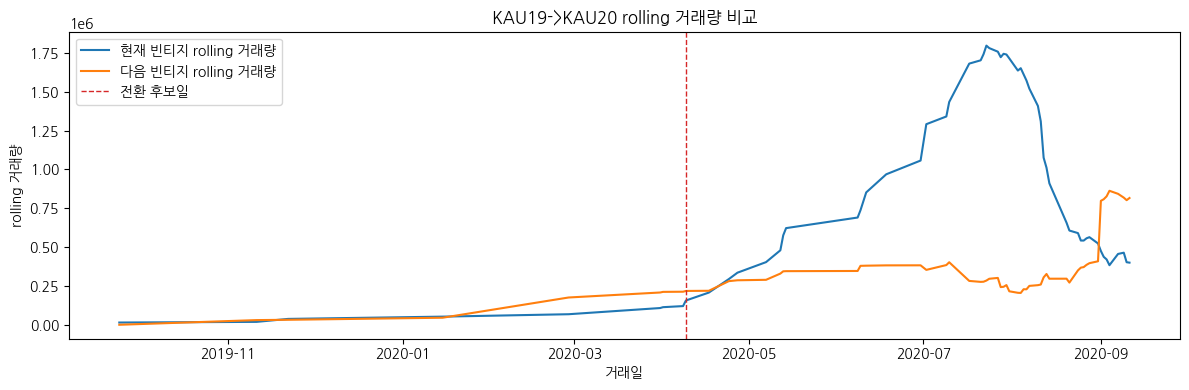

selected_pair = KAU19->KAU20


In [49]:
# 10. 대표 pair의 rolling 거래량 변화 시각화
# selected_pair를 바꾸면 다른 인접 빈티지 pair도 볼 수 있다.

if roll_candidates.empty:
    selected_pair = pair_overlap['pair'].value_counts().idxmax()
else:
    selected_pair = roll_candidates.sort_values('roll_date')['pair'].iloc[0]

selected_trace = roll_traces.get(selected_pair)
if selected_trace is None:
    _, selected_trace = find_volume_confirmed_roll(pair_overlap[pair_overlap['pair'].eq(selected_pair)], **roll_rule_params)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(selected_trace['trd_dd'], selected_trace['current_volume_roll'], label='현재 빈티지 rolling 거래량')
ax.plot(selected_trace['trd_dd'], selected_trace['next_volume_roll'], label='다음 빈티지 rolling 거래량')

if not roll_candidates.empty and selected_pair in set(roll_candidates['pair']):
    roll_date = roll_candidates.loc[roll_candidates['pair'].eq(selected_pair), 'roll_date'].iloc[0]
    ax.axvline(roll_date, color='tab:red', linestyle='--', linewidth=1, label='전환 후보일')

ax.set_title(f'{selected_pair} rolling 거래량 비교')
ax.set_xlabel('거래일')
ax.set_ylabel('rolling 거래량')
ax.legend()
plt.tight_layout()
plt.show()

print('selected_pair =', selected_pair)

In [50]:
# 11. 전환 후보일의 가격 gap 요약
# 가격 gap이 크면 연속 대표 시계열을 만들 때 roll jump 보정 또는 별도 flag가 필요하다.

if roll_candidates.empty:
    roll_price_jump_summary_display = pd.DataFrame({'메시지': ['전환 후보일이 없어 가격 gap을 계산하지 않음']})
else:
    roll_price_jump_summary = roll_candidates[[
        'pair', 'roll_date', 'current_isu_code', 'next_isu_code',
        'current_vwap', 'next_vwap', 'price_ratio_next_to_current',
        'log_price_gap_next_to_current', 'current_volume', 'next_volume'
    ]].copy()

    roll_price_jump_summary_display = roll_price_jump_summary.rename(columns={
        'pair': '빈티지 pair',
        'roll_date': '전환 후보일',
        'current_isu_code': '현재 빈티지',
        'next_isu_code': '다음 빈티지',
        'current_vwap': '현재 VWAP',
        'next_vwap': '다음 VWAP',
        'price_ratio_next_to_current': '가격 비율',
        'log_price_gap_next_to_current': '로그 가격 gap',
        'current_volume': '현재 거래량',
        'next_volume': '다음 거래량',
    })

roll_price_jump_summary_display

,빈티지 pair,전환 후보일,현재 빈티지,다음 빈티지,현재 VWAP,다음 VWAP,가격 비율,로그 가격 gap,현재 거래량,다음 거래량
0,KAU19->KAU20,2020-04-09,KAU19,KAU20,40489,41500,1.02497,0.024663,36000,5000


In [51]:
# 12. 전환 후보 pair 기준 진단용 continuous KAU 시계열 생성
# 이 셀은 전체 KAU15~KAU25 연속 시계열을 확정 생성하지 않는다.
# 기본 roll rule에서 잡힌 전환 후보 pair만 대상으로, 후보일 전에는 현재 빈티지,
# 후보일 이후에는 다음 빈티지를 선택했을 때 가격 계열이 어떻게 보이는지 진단한다.

def build_pair_continuous_series(df, roll_row):
    current_code = roll_row['current_isu_code']
    next_code = roll_row['next_isu_code']
    roll_date = pd.Timestamp(roll_row['roll_date'])
    pair = roll_row['pair']

    pair_df = df[df['isu_code'].isin([current_code, next_code])].copy()
    all_dates = sorted(pair_df['trd_dd'].unique())

    rows = []
    for dt in all_dates:
        selected_code = current_code if dt < roll_date else next_code
        selected = pair_df[
            pair_df['trd_dd'].eq(dt)
            & pair_df['isu_code'].eq(selected_code)
        ]

        if selected.empty:
            continue

        selected = selected.iloc[0]
        rows.append({
            'trd_dd': dt,
            'isu_code': selected_code,
            'vwap': selected['vwap'],
            'acc_trdvol': selected['acc_trdvol'],
            'pair': pair,
            'roll_candidate_date': roll_date,
            'rule_name': (
                f"volume_confirmed_"
                f"w{int(roll_row['rolling_window'])}_"
                f"c{int(roll_row['confirm_days'])}_"
                f"v{int(roll_row['min_next_volume'])}"
            ),
        })

    out = pd.DataFrame(rows).sort_values('trd_dd').reset_index(drop=True)
    if out.empty:
        return out

    out['gap_days'] = out['trd_dd'].diff().dt.days
    out['log_return'] = np.log(out['vwap'] / out['vwap'].shift(1))

    # 첫 행은 roll date가 아닌 후보일 이후 다음 빈티지가 실제로 처음 선택되는 행만 표시한다.
    out['is_roll_date'] = False
    first_next_idx = out.index[
        out['trd_dd'].ge(roll_date)
        & out['isu_code'].eq(next_code)
    ]
    if len(first_next_idx) > 0:
        out.loc[first_next_idx[0], 'is_roll_date'] = True

    return out


if roll_candidates.empty:
    continuous_vwap_candidates = pd.DataFrame()
    continuous_vwap = pd.DataFrame()
    continuous_summary_display = pd.DataFrame({
        '메시지': ['기본 roll rule에서 전환 후보가 없어 진단용 시계열을 생성하지 않음']
    })
else:
    candidate_series = []
    for _, roll_row in roll_candidates.sort_values('roll_date').iterrows():
        candidate_series.append(build_pair_continuous_series(ets_trade, roll_row))

    continuous_vwap_candidates = (
        pd.concat(candidate_series, ignore_index=True)
        if candidate_series
        else pd.DataFrame()
    )

    # 현재는 가장 이른 roll 후보 pair를 대표 진단 대상으로 둔다.
    selected_pair = roll_candidates.sort_values('roll_date')['pair'].iloc[0]
    continuous_vwap = continuous_vwap_candidates[
        continuous_vwap_candidates['pair'].eq(selected_pair)
    ].copy()

    first_roll_date = (
        continuous_vwap.loc[continuous_vwap['is_roll_date'], 'trd_dd'].min()
        if not continuous_vwap.empty
        else pd.NaT
    )

    continuous_summary = pd.DataFrame({
        'pair': [selected_pair],
        'rule_name': [
            continuous_vwap['rule_name'].iloc[0]
            if not continuous_vwap.empty
            else None
        ],
        'obs': [len(continuous_vwap)],
        'start_date': [
            continuous_vwap['trd_dd'].min().date()
            if not continuous_vwap.empty
            else None
        ],
        'end_date': [
            continuous_vwap['trd_dd'].max().date()
            if not continuous_vwap.empty
            else None
        ],
        'roll_candidate_date': [
            continuous_vwap['roll_candidate_date'].iloc[0].date()
            if not continuous_vwap.empty
            else None
        ],
        'first_selected_next_date': [
            first_roll_date.date()
            if pd.notna(first_roll_date)
            else None
        ],
        'roll_event_count': [
            int(continuous_vwap['is_roll_date'].sum())
            if not continuous_vwap.empty
            else 0
        ],
        'median_gap_days': [
            continuous_vwap['gap_days'].median()
            if not continuous_vwap.empty
            else np.nan
        ],
        'p95_gap_days': [
            continuous_vwap['gap_days'].quantile(0.95)
            if not continuous_vwap.empty
            else np.nan
        ],
        'max_gap_days': [
            continuous_vwap['gap_days'].max()
            if not continuous_vwap.empty
            else np.nan
        ],
    })

    continuous_summary_display = continuous_summary.rename(columns={
        'pair': '빈티지 pair',
        'rule_name': '규칙명',
        'obs': '관측치 수',
        'start_date': '시작일',
        'end_date': '종료일',
        'roll_candidate_date': '전환 후보일',
        'first_selected_next_date': '다음 빈티지 첫 선택일',
        'roll_event_count': '표시된 전환 횟수',
        'median_gap_days': '관측치 간 경과일 중앙값',
        'p95_gap_days': '관측치 간 경과일 95% 분위',
        'max_gap_days': '관측치 간 최대 경과일',
    })

continuous_summary_display

,빈티지 pair,규칙명,관측치 수,시작일,종료일,전환 후보일,다음 빈티지 첫 선택일,표시된 전환 횟수,관측치 간 경과일 중앙값,관측치 간 경과일 95% 분위,관측치 간 최대 경과일
0,KAU19->KAU20,volume_confirmed_w20_c5_v1000,461,2019-01-22,2021-08-09,2020-04-09,2020-04-09,1,1.0,5.0,90.0


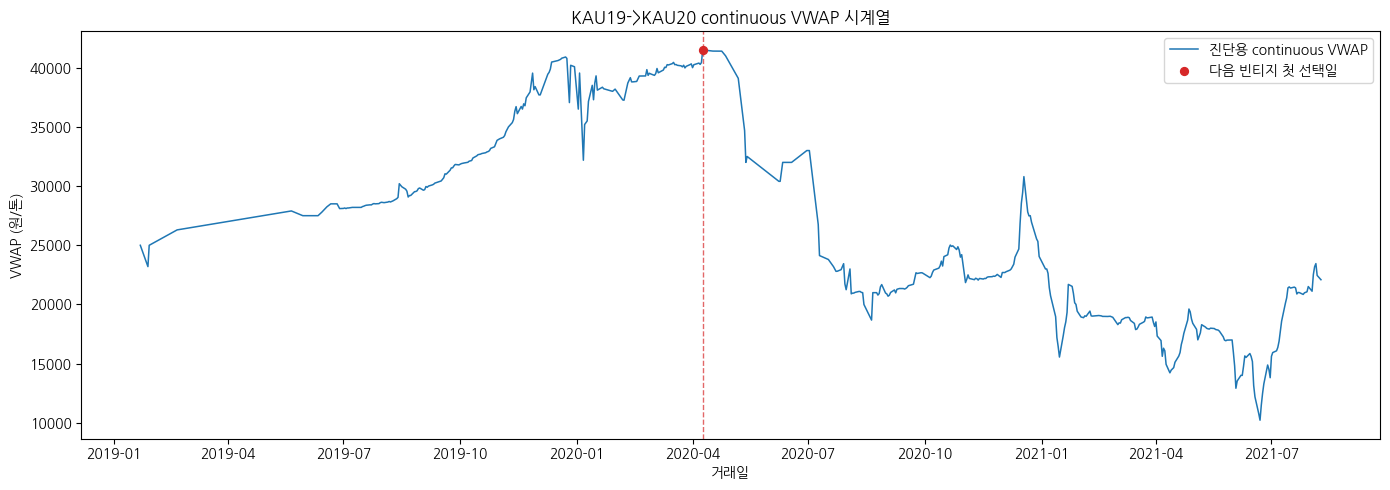

In [56]:
# 13. 진단용 continuous VWAP 시계열 시각화
# Cell 12에서 선택한 roll 후보 pair 기준으로만 시각화한다.

if continuous_vwap.empty:
    print('진단용 continuous VWAP 시계열이 비어 있어 그래프를 생성하지 않음')
else:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        continuous_vwap['trd_dd'],
        continuous_vwap['vwap'],
        linewidth=1.1,
        label='진단용 continuous VWAP',
    )

    roll_points = continuous_vwap[continuous_vwap['is_roll_date']]
    if not roll_points.empty:
        ax.scatter(
            roll_points['trd_dd'],
            roll_points['vwap'],
            color='tab:red',
            s=32,
            zorder=3,
            label='다음 빈티지 첫 선택일',
        )

        for _, row in roll_points.iterrows():
            ax.axvline(
                row['trd_dd'],
                color='tab:red',
                linestyle='--',
                linewidth=1,
                alpha=0.7,
            )

    title_pair = (
        continuous_vwap['pair'].iloc[0]
        if 'pair' in continuous_vwap.columns and not continuous_vwap.empty
        else '선택 pair'
    )
    rule_name = (
        continuous_vwap['rule_name'].iloc[0]
        if 'rule_name' in continuous_vwap.columns and not continuous_vwap.empty
        else ''
    )

    ax.set_title(f'{title_pair} continuous VWAP 시계열')
    ax.set_xlabel('거래일')
    ax.set_ylabel('VWAP (원/톤)')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [53]:
# 14. 빈티지 의사결정 항목 요약
# roll 후보 존재 여부와 별도로, 후보일 이후 거래량 우위가 유지되는지 확인한다.

stability_rows = []

if not roll_candidates.empty:
    for _, row in roll_candidates.sort_values('roll_date').iterrows():
        pair = row['pair']
        trace = roll_traces.get(pair)

        if trace is None or trace.empty:
            continue

        post_trace = trace[trace['trd_dd'].ge(row['roll_date'])].copy()

        stability_rows.append({
            'pair': pair,
            'roll_date': row['roll_date'],
            'post_overlap_days': len(post_trace),
            'post_next_roll_gt_days': (
                int(post_trace['next_roll_gt_current_roll'].sum())
                if not post_trace.empty
                else 0
            ),
            'post_next_roll_gt_rate': (
                float(post_trace['next_roll_gt_current_roll'].mean())
                if not post_trace.empty
                else np.nan
            ),
            'post_current_roll_ge_days': (
                int((~post_trace['next_roll_gt_current_roll']).sum())
                if not post_trace.empty
                else 0
            ),
            'price_ratio_next_to_current': row['price_ratio_next_to_current'],
            'log_price_gap_next_to_current': row['log_price_gap_next_to_current'],
        })

roll_stability = pd.DataFrame(stability_rows)

if roll_stability.empty:
    roll_stability_display = pd.DataFrame({
        '메시지': ['전환 후보일 이후 안정성 계산 대상 없음']
    })
    post_stability_judgement = '미확인'
else:
    roll_stability_display = roll_stability.rename(columns={
        'pair': '빈티지 pair',
        'roll_date': '전환 후보일',
        'post_overlap_days': '후보일 이후 동시 거래일 수',
        'post_next_roll_gt_days': '이후 다음 rolling 우위일 수',
        'post_next_roll_gt_rate': '이후 다음 rolling 우위 비율',
        'post_current_roll_ge_days': '이후 현재 우위/동률일 수',
        'price_ratio_next_to_current': '전환일 가격 비율',
        'log_price_gap_next_to_current': '전환일 로그 가격 gap',
    })

    min_stability_rate = 0.5
    post_stability_judgement = (
        '확인'
        if roll_stability['post_next_roll_gt_rate'].ge(min_stability_rate).all()
        else '추가 검토 필요'
    )

continuous_judgement = (
    '후보 pair 진단 가능'
    if not continuous_vwap.empty
    else '미확인'
)

decision_check = pd.DataFrame({
    '항목': [
        '인접 빈티지 동시 거래 구간 존재',
        'volume-confirmed roll 후보 존재',
        '후보일 이후 다음 빈티지 우위 지속성',
        '전환 후보일 가격 gap 확인',
        '진단용 continuous VWAP 시계열 생성',
        '최종 continuous 타겟 저장 여부',
    ],
    '현재 판단': [
        '확인' if not pair_overlap.empty else '미확인',
        f'확인 ({len(roll_candidates):,}개 후보)' if not roll_candidates.empty else '미확인',
        post_stability_judgement,
        '확인 필요' if roll_candidates.empty else '확인됨, 해석 필요',
        continuous_judgement,
        '아직 저장하지 않음',
    ],
})

display(roll_stability_display)
decision_check

,빈티지 pair,전환 후보일,후보일 이후 동시 거래일 수,이후 다음 rolling 우위일 수,이후 다음 rolling 우위 비율,이후 현재 우위/동률일 수,전환일 가격 비율,전환일 로그 가격 gap
0,KAU19->KAU20,2020-04-09,52,10,0.192308,42,1.02497,0.024663


,항목,현재 판단
0,인접 빈티지 동시 거래 구간 존재,확인
1,volume-confirmed roll 후보 존재,확인 (1개 후보)
2,후보일 이후 다음 빈티지 우위 지속성,추가 검토 필요
3,전환 후보일 가격 gap 확인,"확인됨, 해석 필요"
4,진단용 continuous VWAP 시계열 생성,후보 pair 진단 가능
5,최종 continuous 타겟 저장 여부,아직 저장하지 않음


# 결론

- 인접한 빈티지들의 동시 거래 구간은 확인되었다.
- `volume_confirmed_w20_c5_v1000` 조건에서는 `KAU19→KAU20` 1개 후보만 확인되었다.
- 전환 후보일의 가격 비율은 약 1.025로, roll jump 해석이 필요하다.
- 후보일 이후 동시 거래 구간에서 다음 빈티지 rolling 거래량 우위 비율은 약 19.2%에 그쳤다.
- 따라서 현재 조건의 `volume_confirmed_roll`은 최종 continuous target으로 바로 채택하지 않고, 보조 후보로 보류한다.
- 다음 단계에서는 `same_vintage_panel` 기준 30일/60일 VWAP 로그수익률을 우선 검증한다.